# Marquez — Data Lineage in Action
### Practical Demo: Tracking a Smart Metering Pipeline with OpenLineage

**Prathamesh Patil** | Mat. Nr. 838598 
**Topic:** Marquez — Data Lineage Platform (Observability Layer)

M.Sc. Big Data & Business Analytics — FOM Hochschule Essen  
Module: Applied Programming | Er,Mustafa  
Summer Semester 2026

---

This notebook demonstrates a **real-world data pipeline** that:
1. Ingests real household energy consumption data (UCI ML Repository)
2. Runs **7 data quality checks** to detect sensor anomalies
3. Transforms data into consumption metrics with cost & CO₂ calculations
4. Generates a sustainability report
5. **Emits OpenLineage events to Marquez** at every stage — including FAIL events for bad data

**Prerequisites:** Marquez running via Docker (`docker-compose up -d`)

## 0. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import requests
import uuid
import zipfile
import io
import os
import warnings
from datetime import datetime, timezone

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 15)
pd.set_option('display.width', 120)

# Marquez API configuration
MARQUEZ_URL = "http://localhost:9000/api/v1/lineage"
NAMESPACE = "smart-metering-pipeline"
PRODUCER = "https://github.com/prathameshpatil24/marquez-smart-metering-demo"

# Verify Marquez is running
try:
    r = requests.get("http://localhost:9000/api/v1/namespaces", timeout=5)
    print(f"✅ Marquez API is running — {r.status_code}")
    print(f"   Namespaces: {[ns['name'] for ns in r.json()['namespaces']]}")
except:
    print("❌ Marquez API not reachable. Run: docker-compose up -d")

✅ Marquez API is running — 200
   Namespaces: ['default']


/Users/prathameshpatil/minerva-prep/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## 1. OpenLineage Helper Functions

These functions build and send **OpenLineage-compliant events** to Marquez.  
Each pipeline stage emits a `START` event when it begins and a `COMPLETE` or `FAIL` event when it finishes.

In [2]:
def emit_lineage_event(event_type, run_id, job_name, inputs=None, outputs=None,
                       job_facets=None, run_facets=None):
    """Send an OpenLineage event to Marquez."""
    event = {
        "eventType": event_type,
        "eventTime": datetime.now(timezone.utc).isoformat(),
        "run": {"runId": run_id},
        "job": {"namespace": NAMESPACE, "name": job_name},
        "inputs": inputs or [],
        "outputs": outputs or [],
        "producer": PRODUCER,
        "schemaURL": "https://openlineage.io/spec/1-0-5/OpenLineage.json#/definitions/RunEvent",
    }
    if run_facets:
        event["run"]["facets"] = run_facets
    if job_facets:
        event["job"]["facets"] = job_facets

    try:
        resp = requests.post(MARQUEZ_URL, json=event, timeout=10)
        symbol = {"START": "🟡", "COMPLETE": "🟢", "FAIL": "🔴"}[event_type]
        print(f"  {symbol} Lineage event sent: {event_type} for '{job_name}'")
        return resp.status_code == 201
    except Exception as e:
        print(f"  ⚠️ Failed to send event: {e}")
        return False


def make_dataset(name, schema_fields=None, row_count=None, source_name=None, source_uri=None):
    """Build an OpenLineage dataset entry with optional facets."""
    ds = {"namespace": NAMESPACE, "name": name}
    facets = {}
    if schema_fields:
        facets["schema"] = {
            "_producer": PRODUCER,
            "_schemaURL": "https://openlineage.io/spec/facets/1-0-0/SchemaDatasetFacet.json",
            "fields": [{"name": n, "type": t} for n, t in schema_fields],
        }
    if row_count is not None:
        facets["dataQualityMetrics"] = {
            "_producer": PRODUCER,
            "_schemaURL": "https://openlineage.io/spec/facets/1-0-0/DataQualityMetricsInputDatasetFacet.json",
            "rowCount": row_count,
        }
    if source_name:
        facets["dataSource"] = {
            "_producer": PRODUCER,
            "_schemaURL": "https://openlineage.io/spec/facets/1-0-0/DatasourceDatasetFacet.json",
            "name": source_name, "uri": source_uri or "",
        }
    if facets:
        ds["facets"] = facets
    return ds


def make_sql_facet(query):
    """Build a SQL job facet."""
    return {"sql": {
        "_producer": PRODUCER,
        "_schemaURL": "https://openlineage.io/spec/facets/1-0-0/SQLJobFacet.json",
        "query": query,
    }}


def make_error_facet(message):
    """Build an error message run facet."""
    return {"errorMessage": {
        "_producer": PRODUCER,
        "_schemaURL": "https://openlineage.io/spec/facets/1-0-1/ErrorMessageRunFacet.json",
        "message": message, "programmingLanguage": "Python",
    }}


print("✅ OpenLineage helper functions loaded")

✅ OpenLineage helper functions loaded


## 2. Download Real-World Energy Data

We use the **UCI Individual Household Electric Power Consumption** dataset — real measurements from a house in Sceaux, France (2006–2010).  
- **2,075,259 readings** collected every minute
- **~1.25% naturally missing values** (real sensor gaps)
- Includes: voltage, current intensity, active/reactive power, sub-metering

📖 Source: [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/235)

In [3]:
DATA_URL = "https://archive.ics.uci.edu/static/public/235/individual+household+electric+power+consumption.zip"
DATA_FILE = "data/household_power_consumption.txt"

os.makedirs("data", exist_ok=True)

if not os.path.exists(DATA_FILE):
    print("📥 Downloading UCI Household Power Consumption dataset...")
    resp = requests.get(DATA_URL, timeout=60)
    with zipfile.ZipFile(io.BytesIO(resp.content)) as z:
        # Extract the text file
        for name in z.namelist():
            if name.endswith('.txt'):
                with z.open(name) as f:
                    with open(DATA_FILE, 'wb') as out:
                        out.write(f.read())
                print(f"   ✅ Extracted: {name} → {DATA_FILE}")
                break
else:
    print(f"✅ Dataset already exists: {DATA_FILE}")

print(f"   📦 File size: {os.path.getsize(DATA_FILE) / 1024 / 1024:.1f} MB")

📥 Downloading UCI Household Power Consumption dataset...
   ✅ Extracted: household_power_consumption.txt → data/household_power_consumption.txt
   📦 File size: 126.8 MB


---
# 🔄 Pipeline Execution

```
[UCI Raw Data] → INGEST → [staged_readings] → VALIDATE → [validated_readings] → TRANSFORM → [consumption_metrics] → AGGREGATE → [building_sustainability_report]
```

Each stage emits OpenLineage events to Marquez. Open the **Marquez UI at http://localhost:3000** to watch the lineage graph build in real time.

## Stage 1: INGEST — Load Raw Meter Data

In [4]:
run_id_ingest = str(uuid.uuid4())
JOB_INGEST = "ingest-meter-readings"

# ── Emit START
emit_lineage_event("START", run_id_ingest, JOB_INGEST,
    inputs=[make_dataset("raw_power_consumption",
        source_name="UCI-ML-Repository",
        source_uri="https://archive.ics.uci.edu/dataset/235"
    )]
)

# ── Read the dataset
df_raw = pd.read_csv(
    DATA_FILE, sep=';',
    low_memory=False,
    na_values='?',  # UCI uses '?' for missing values
)

# Combine Date + Time into a single timestamp
df_raw['timestamp'] = pd.to_datetime(
    df_raw['Date'] + ' ' + df_raw['Time'],
    format='%d/%m/%Y %H:%M:%S',
    errors='coerce'
)

# Take a sample for demo (last 30 days of data)
df_raw = df_raw.sort_values('timestamp')
cutoff = df_raw['timestamp'].max() - pd.Timedelta(days=30)
df = df_raw[df_raw['timestamp'] >= cutoff].copy().reset_index(drop=True)

row_count = len(df)

print(f"\n📊 Dataset Summary (last 30 days):")
print(f"   Total rows:    {row_count:,}")
print(f"   Date range:    {df['timestamp'].min()} → {df['timestamp'].max()}")
print(f"   Columns:       {list(df.columns)}")
print(f"   Missing values:")
for col in df.columns:
    missing = df[col].isna().sum()
    if missing > 0:
        print(f"     {col}: {missing} ({missing/row_count*100:.2f}%)")

# ── Emit COMPLETE
schema = [
    ("Date", "VARCHAR"), ("Time", "VARCHAR"),
    ("Global_active_power", "DOUBLE"), ("Global_reactive_power", "DOUBLE"),
    ("Voltage", "DOUBLE"), ("Global_intensity", "DOUBLE"),
    ("Sub_metering_1", "DOUBLE"), ("Sub_metering_2", "DOUBLE"),
    ("Sub_metering_3", "DOUBLE"), ("timestamp", "TIMESTAMP"),
]
emit_lineage_event("COMPLETE", run_id_ingest, JOB_INGEST,
    inputs=[make_dataset("raw_power_consumption")],
    outputs=[make_dataset("staged_readings", schema_fields=schema, row_count=row_count)],
)

df.head(10)

  🟡 Lineage event sent: START for 'ingest-meter-readings'

📊 Dataset Summary (last 30 days):
   Total rows:    43,201
   Date range:    2010-10-27 21:02:00 → 2010-11-26 21:02:00
   Columns:       ['Date', 'Time', 'Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'timestamp']
   Missing values:
  🟢 Lineage event sent: COMPLETE for 'ingest-meter-readings'


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,timestamp
0,27/10/2010,21:02:00,0.498,0.300,240.64,2.4,0.0,1.0,1.0,2010-10-27 21:02:00
1,27/10/2010,21:03:00,0.490,0.290,240.57,2.4,0.0,1.0,0.0,2010-10-27 21:03:00
2,27/10/2010,21:04:00,0.426,0.198,240.77,1.8,0.0,1.0,1.0,2010-10-27 21:04:00
3,27/10/2010,21:05:00,0.424,0.198,240.81,1.8,0.0,2.0,0.0,2010-10-27 21:05:00
4,27/10/2010,21:06:00,0.426,0.200,241.15,1.8,0.0,1.0,1.0,2010-10-27 21:06:00
5,27/10/2010,21:07:00,0.426,0.204,242.17,1.8,0.0,1.0,1.0,2010-10-27 21:07:00
6,27/10/2010,21:08:00,0.428,0.206,242.76,2.0,0.0,1.0,0.0,2010-10-27 21:08:00
7,27/10/2010,21:09:00,0.368,0.122,243.36,1.6,0.0,1.0,1.0,2010-10-27 21:09:00
8,27/10/2010,21:10:00,0.336,0.074,243.81,1.4,0.0,1.0,1.0,2010-10-27 21:10:00
9,27/10/2010,21:11:00,0.334,0.070,242.87,1.4,0.0,2.0,0.0,2010-10-27 21:11:00


## Stage 2: VALIDATE — Data Quality Checks

We run **7 data quality checks** on the real sensor data. The UCI dataset has natural missing values (sensor gaps), which makes this validation realistic — we're detecting **actual** data quality issues, not artificially injected ones.

**Rule:** If error rate exceeds **20%**, the pipeline **FAILS** and emits a `FAIL` event to Marquez.

In [5]:
run_id_validate = str(uuid.uuid4())
JOB_VALIDATE = "validate-readings"
MAX_ERROR_RATE = 0.20

# ── Emit START
emit_lineage_event("START", run_id_validate, JOB_VALIDATE,
    inputs=[make_dataset("staged_readings")]
)

print("\n🔍 Running Data Quality Checks...\n")
issues = []
total_rows = len(df)

# Check 1: Missing Global_active_power (primary reading)
null_power = df['Global_active_power'].isna().sum()
status = "❌ FAILED" if null_power > 0 else "✅ PASSED"
print(f"  {status} | Check 1 — Null active power:      {null_power} rows")
if null_power > 0:
    issues.append(f"NULL Global_active_power: {null_power} rows")

# Check 2: Missing Voltage readings
null_voltage = df['Voltage'].isna().sum()
status = "❌ FAILED" if null_voltage > 0 else "✅ PASSED"
print(f"  {status} | Check 2 — Null voltage:            {null_voltage} rows")
if null_voltage > 0:
    issues.append(f"NULL Voltage: {null_voltage} rows")

# Check 3: Missing sub-metering values
null_sub = df[['Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']].isna().any(axis=1).sum()
status = "❌ FAILED" if null_sub > 0 else "✅ PASSED"
print(f"  {status} | Check 3 — Null sub-metering:       {null_sub} rows")
if null_sub > 0:
    issues.append(f"NULL sub-metering: {null_sub} rows")

# Check 4: Negative power readings (physically impossible)
negative_power = (df['Global_active_power'].fillna(0) < 0).sum()
status = "❌ FAILED" if negative_power > 0 else "✅ PASSED"
print(f"  {status} | Check 4 — Negative power readings: {negative_power} rows")
if negative_power > 0:
    issues.append(f"Negative power: {negative_power} rows")

# Check 5: Voltage out of safe range (<200V or >260V for EU)
voltage_outliers = ((df['Voltage'].fillna(230) < 200) | (df['Voltage'].fillna(230) > 260)).sum()
status = "❌ FAILED" if voltage_outliers > 0 else "✅ PASSED"
print(f"  {status} | Check 5 — Voltage out of range:    {voltage_outliers} rows")
if voltage_outliers > 0:
    issues.append(f"Voltage out of range (200-260V): {voltage_outliers} rows")

# Check 6: Impossibly high power (>11kW for residential)
high_power = (df['Global_active_power'].fillna(0) > 11).sum()
status = "❌ FAILED" if high_power > 0 else "✅ PASSED"
print(f"  {status} | Check 6 — Power > 11kW:            {high_power} rows")
if high_power > 0:
    issues.append(f"Power > 11kW: {high_power} rows")

# Check 7: Invalid timestamps
null_ts = df['timestamp'].isna().sum()
status = "❌ FAILED" if null_ts > 0 else "✅ PASSED"
print(f"  {status} | Check 7 — Invalid timestamps:      {null_ts} rows")
if null_ts > 0:
    issues.append(f"Invalid timestamp: {null_ts} rows")

# ── Calculate error rate
problem_mask = (
    df['Global_active_power'].isna()
    | df['Voltage'].isna()
    | df[['Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']].isna().any(axis=1)
    | (df['Global_active_power'].fillna(0) < 0)
    | (df['Voltage'].fillna(230) < 200) | (df['Voltage'].fillna(230) > 260)
    | (df['Global_active_power'].fillna(0) > 11)
    | df['timestamp'].isna()
)
error_count = problem_mask.sum()
error_rate = error_count / total_rows

print(f"\n📊 Quality Summary:")
print(f"   Total rows:    {total_rows:,}")
print(f"   Clean rows:    {total_rows - error_count:,}")
print(f"   Problem rows:  {error_count:,}")
print(f"   Error rate:    {error_rate:.2%} (threshold: {MAX_ERROR_RATE:.0%})")

  🟡 Lineage event sent: START for 'validate-readings'

🔍 Running Data Quality Checks...

  ✅ PASSED | Check 1 — Null active power:      0 rows
  ✅ PASSED | Check 2 — Null voltage:            0 rows
  ✅ PASSED | Check 3 — Null sub-metering:       0 rows
  ✅ PASSED | Check 4 — Negative power readings: 0 rows
  ✅ PASSED | Check 5 — Voltage out of range:    0 rows
  ✅ PASSED | Check 6 — Power > 11kW:            0 rows
  ✅ PASSED | Check 7 — Invalid timestamps:      0 rows

📊 Quality Summary:
   Total rows:    43,201
   Clean rows:    43,201
   Problem rows:  0
   Error rate:    0.00% (threshold: 20%)


In [6]:
# ── Decision: PASS or FAIL

if error_rate > MAX_ERROR_RATE:
    error_msg = (
        f"Data quality check FAILED — error rate {error_rate:.1%} exceeds "
        f"threshold {MAX_ERROR_RATE:.0%}. Issues: {'; '.join(issues)}"
    )
    print(f"\n🚨 PIPELINE HALTED — Error rate too high!")
    emit_lineage_event("FAIL", run_id_validate, JOB_VALIDATE,
        inputs=[make_dataset("staged_readings")],
        run_facets=make_error_facet(error_msg),
    )
    raise RuntimeError(error_msg)
else:
    # Filter out bad rows
    df_clean = df[~problem_mask].copy().reset_index(drop=True)
    clean_count = len(df_clean)

    print(f"\n✅ Validation PASSED — {clean_count:,} clean rows forwarded")
    print(f"   {error_count:,} rows removed during validation")

    emit_lineage_event("COMPLETE", run_id_validate, JOB_VALIDATE,
        inputs=[make_dataset("staged_readings")],
        outputs=[make_dataset("validated_readings",
            schema_fields=schema, row_count=clean_count)],
        job_facets=make_sql_facet(
            "SELECT * FROM staged_readings "
            "WHERE Global_active_power IS NOT NULL "
            "AND Voltage BETWEEN 200 AND 260 "
            "AND Global_active_power BETWEEN 0 AND 11 "
            "AND timestamp IS NOT NULL"
        ),
    )

df_clean.head()


✅ Validation PASSED — 43,201 clean rows forwarded
   0 rows removed during validation
  🟢 Lineage event sent: COMPLETE for 'validate-readings'


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,timestamp
0,27/10/2010,21:02:00,0.498,0.300,240.64,2.4,0.0,1.0,1.0,2010-10-27 21:02:00
1,27/10/2010,21:03:00,0.490,0.290,240.57,2.4,0.0,1.0,0.0,2010-10-27 21:03:00
2,27/10/2010,21:04:00,0.426,0.198,240.77,1.8,0.0,1.0,1.0,2010-10-27 21:04:00
3,27/10/2010,21:05:00,0.424,0.198,240.81,1.8,0.0,2.0,0.0,2010-10-27 21:05:00
4,27/10/2010,21:06:00,0.426,0.200,241.15,1.8,0.0,1.0,1.0,2010-10-27 21:06:00


## Stage 3: TRANSFORM — Calculate Consumption Metrics

Enrich each reading with:
- **Energy (kWh):** `Global_active_power × (1 min / 60 min)`
- **Cost (EUR):** Using German energy price €0.35/kWh
- **CO₂ (kg):** Using German grid factor 0.38 kg CO₂/kWh

In [7]:
run_id_transform = str(uuid.uuid4())
JOB_TRANSFORM = "calculate-consumption-metrics"

# ── Emit START
emit_lineage_event("START", run_id_transform, JOB_TRANSFORM,
    inputs=[make_dataset("validated_readings")]
)

# Energy price and CO2 factor (Germany 2026)
PRICE_PER_KWH = 0.35   # EUR
CO2_PER_KWH = 0.38     # kg CO₂ (German electricity grid mix)

# Calculate energy in kWh (power in kW × 1 minute / 60 = kWh per reading)
df_clean['energy_kwh'] = (df_clean['Global_active_power'] * (1/60)).round(4)
df_clean['cost_eur'] = (df_clean['energy_kwh'] * PRICE_PER_KWH).round(4)
df_clean['co2_kg'] = (df_clean['energy_kwh'] * CO2_PER_KWH).round(4)

# Add date column for aggregation
df_clean['date'] = df_clean['timestamp'].dt.date
df_clean['hour'] = df_clean['timestamp'].dt.hour

total_energy = df_clean['energy_kwh'].sum()
total_cost = df_clean['cost_eur'].sum()
total_co2 = df_clean['co2_kg'].sum()

print(f"\n⚡ Consumption Metrics Calculated:")
print(f"   Total energy:     {total_energy:,.2f} kWh")
print(f"   Total cost:       €{total_cost:,.2f}")
print(f"   Total CO₂:        {total_co2:,.2f} kg")
print(f"   Avg daily energy: {total_energy / 30:,.2f} kWh/day")
print(f"   Avg daily cost:   €{total_cost / 30:,.2f}/day")
print(f"   Rows enriched:    {len(df_clean):,}")

# Save intermediate output
os.makedirs('output', exist_ok=True)
df_clean.to_csv('output/consumption_metrics.csv', index=False)
print(f"   💾 Saved to: output/consumption_metrics.csv")

# ── Emit COMPLETE
enriched_schema = schema + [
    ("energy_kwh", "DOUBLE"), ("cost_eur", "DOUBLE"),
    ("co2_kg", "DOUBLE"), ("date", "DATE"), ("hour", "INTEGER"),
]
emit_lineage_event("COMPLETE", run_id_transform, JOB_TRANSFORM,
    inputs=[make_dataset("validated_readings")],
    outputs=[make_dataset("consumption_metrics",
        schema_fields=enriched_schema, row_count=len(df_clean))],
    job_facets=make_sql_facet(
        "SELECT *, "
        "Global_active_power * (1/60) AS energy_kwh, "
        "energy_kwh * 0.35 AS cost_eur, "
        "energy_kwh * 0.38 AS co2_kg "
        "FROM validated_readings"
    ),
)

df_clean.head()

  🟡 Lineage event sent: START for 'calculate-consumption-metrics'

⚡ Consumption Metrics Calculated:
   Total energy:     850.23 kWh
   Total cost:       €297.52
   Total CO₂:        323.07 kg
   Avg daily energy: 28.34 kWh/day
   Avg daily cost:   €9.92/day
   Rows enriched:    43,201
   💾 Saved to: output/consumption_metrics.csv
  🟢 Lineage event sent: COMPLETE for 'calculate-consumption-metrics'


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,timestamp,energy_kwh,cost_eur,co2_kg,date,hour
0,27/10/2010,21:02:00,0.498,0.300,240.64,2.4,0.0,1.0,1.0,2010-10-27 21:02:00,0.0083,0.0029,0.0032,2010-10-27,21
1,27/10/2010,21:03:00,0.490,0.290,240.57,2.4,0.0,1.0,0.0,2010-10-27 21:03:00,0.0082,0.0029,0.0031,2010-10-27,21
2,27/10/2010,21:04:00,0.426,0.198,240.77,1.8,0.0,1.0,1.0,2010-10-27 21:04:00,0.0071,0.0025,0.0027,2010-10-27,21
3,27/10/2010,21:05:00,0.424,0.198,240.81,1.8,0.0,2.0,0.0,2010-10-27 21:05:00,0.0071,0.0025,0.0027,2010-10-27,21
4,27/10/2010,21:06:00,0.426,0.200,241.15,1.8,0.0,1.0,1.0,2010-10-27 21:06:00,0.0071,0.0025,0.0027,2010-10-27,21


## Stage 4: AGGREGATE — Sustainability Report

Generate a **daily sustainability report** with total consumption, cost, and CO₂ emissions.

In [8]:
run_id_aggregate = str(uuid.uuid4())
JOB_AGGREGATE = "generate-sustainability-report"

# ── Emit START
emit_lineage_event("START", run_id_aggregate, JOB_AGGREGATE,
    inputs=[make_dataset("consumption_metrics")]
)

# Daily aggregation
daily_report = df_clean.groupby('date').agg(
    total_readings=('energy_kwh', 'count'),
    total_energy_kwh=('energy_kwh', 'sum'),
    avg_power_kw=('Global_active_power', 'mean'),
    max_power_kw=('Global_active_power', 'max'),
    avg_voltage=('Voltage', 'mean'),
    total_cost_eur=('cost_eur', 'sum'),
    total_co2_kg=('co2_kg', 'sum'),
).round(2).reset_index()

# Hourly pattern (for visualization)
hourly_pattern = df_clean.groupby('hour').agg(
    avg_power_kw=('Global_active_power', 'mean'),
    avg_energy_kwh=('energy_kwh', 'mean'),
).round(4).reset_index()

# Save reports
daily_report.to_csv('output/daily_sustainability_report.csv', index=False)
hourly_pattern.to_csv('output/hourly_consumption_pattern.csv', index=False)

print(f"\n📊 Sustainability Report Generated:")
print(f"   Period:          {daily_report['date'].min()} → {daily_report['date'].max()}")
print(f"   Days covered:    {len(daily_report)}")
print(f"   Total energy:    {daily_report['total_energy_kwh'].sum():,.2f} kWh")
print(f"   Total cost:      €{daily_report['total_cost_eur'].sum():,.2f}")
print(f"   Total CO₂:       {daily_report['total_co2_kg'].sum():,.2f} kg")
print(f"\n   💾 Saved: output/daily_sustainability_report.csv")
print(f"   💾 Saved: output/hourly_consumption_pattern.csv")

# ── Emit COMPLETE
report_schema = [
    ("date", "DATE"), ("total_readings", "INTEGER"),
    ("total_energy_kwh", "DOUBLE"), ("avg_power_kw", "DOUBLE"),
    ("max_power_kw", "DOUBLE"), ("avg_voltage", "DOUBLE"),
    ("total_cost_eur", "DOUBLE"), ("total_co2_kg", "DOUBLE"),
]
emit_lineage_event("COMPLETE", run_id_aggregate, JOB_AGGREGATE,
    inputs=[make_dataset("consumption_metrics")],
    outputs=[make_dataset("daily_sustainability_report",
        schema_fields=report_schema, row_count=len(daily_report))],
    job_facets=make_sql_facet(
        "SELECT date, COUNT(*) AS total_readings, "
        "SUM(energy_kwh) AS total_energy_kwh, "
        "AVG(Global_active_power) AS avg_power_kw, "
        "SUM(cost_eur) AS total_cost_eur, "
        "SUM(co2_kg) AS total_co2_kg "
        "FROM consumption_metrics GROUP BY date"
    ),
)

daily_report

  🟡 Lineage event sent: START for 'generate-sustainability-report'

📊 Sustainability Report Generated:
   Period:          2010-10-27 → 2010-11-26
   Days covered:    31
   Total energy:    850.24 kWh
   Total cost:      €297.51
   Total CO₂:       323.08 kg

   💾 Saved: output/daily_sustainability_report.csv
   💾 Saved: output/hourly_consumption_pattern.csv
  🟢 Lineage event sent: COMPLETE for 'generate-sustainability-report'


,date,total_readings,total_energy_kwh,avg_power_kw,max_power_kw,avg_voltage,total_cost_eur,total_co2_kg
0,2010-10-27,178,1.97,0.66,3.86,247.27,0.69,0.75
1,2010-10-28,1440,24.39,1.02,5.29,246.25,8.53,9.27
2,2010-10-29,1440,20.07,0.84,4.05,245.74,7.02,7.63
3,2010-10-30,1440,35.88,1.49,5.02,243.27,12.56,13.63
4,2010-10-31,1440,24.61,1.03,4.70,245.50,8.61,9.35
5,2010-11-01,1440,23.05,0.96,2.86,246.38,8.07,8.76
6,2010-11-02,1440,19.85,0.83,3.15,245.79,6.95,7.54
7,2010-11-03,1440,21.55,0.90,5.03,244.28,7.54,8.19
8,2010-11-04,1440,42.58,1.77,8.13,243.15,14.90,16.18
9,2010-11-05,1440,28.94,1.21,5.37,243.78,10.12,11.00


## 📈 Visualization — Daily Energy Consumption

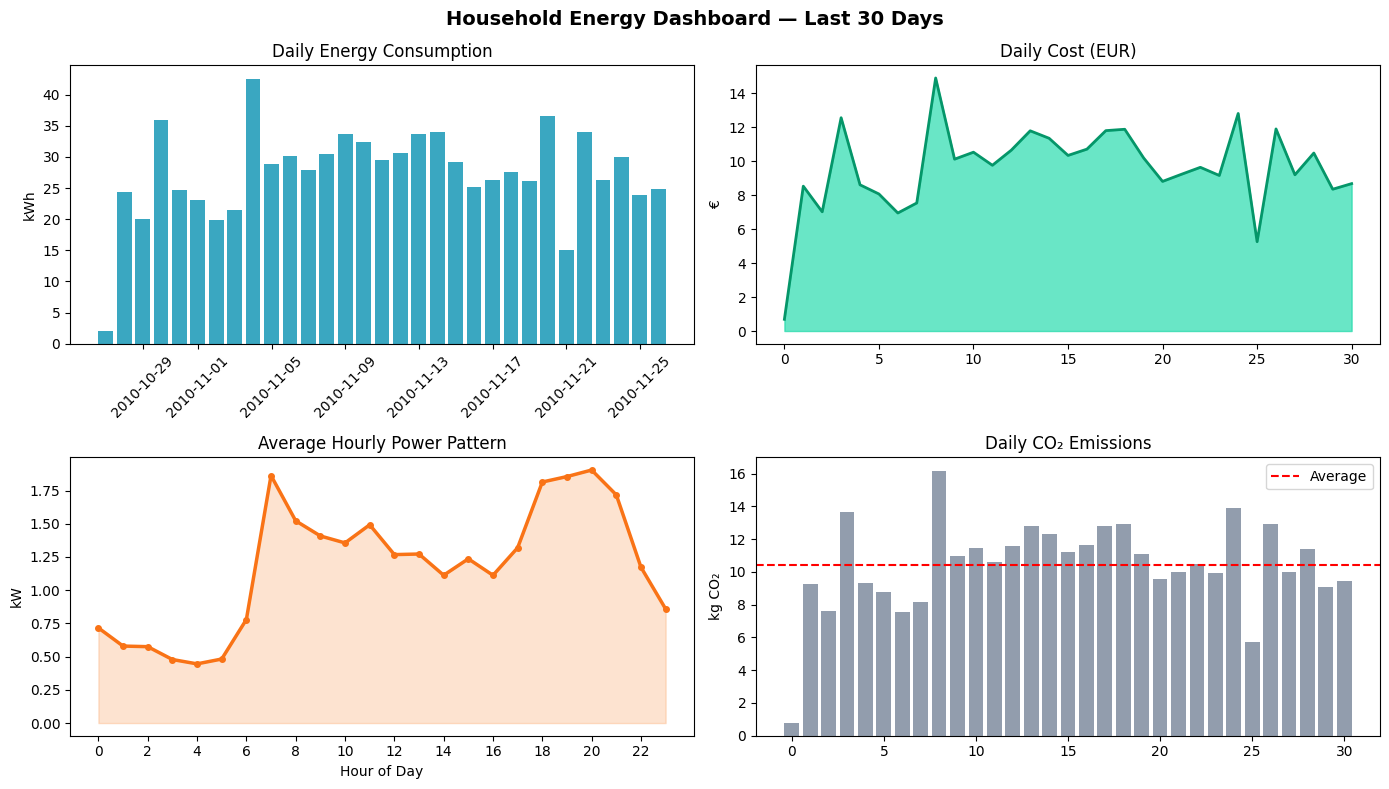

💾 Saved: output/energy_dashboard.png


In [9]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Household Energy Dashboard — Last 30 Days', fontsize=14, fontweight='bold')

# 1. Daily energy consumption
ax1 = axes[0, 0]
ax1.bar(daily_report['date'], daily_report['total_energy_kwh'], color='#0891B2', alpha=0.8)
ax1.set_title('Daily Energy Consumption')
ax1.set_ylabel('kWh')
ax1.tick_params(axis='x', rotation=45)

# 2. Daily cost
ax2 = axes[0, 1]
ax2.fill_between(range(len(daily_report)), daily_report['total_cost_eur'], color='#06D6A0', alpha=0.6)
ax2.plot(range(len(daily_report)), daily_report['total_cost_eur'], color='#059669', linewidth=2)
ax2.set_title('Daily Cost (EUR)')
ax2.set_ylabel('€')

# 3. Hourly consumption pattern
ax3 = axes[1, 0]
ax3.plot(hourly_pattern['hour'], hourly_pattern['avg_power_kw'], 
         color='#F97316', linewidth=2.5, marker='o', markersize=4)
ax3.fill_between(hourly_pattern['hour'], hourly_pattern['avg_power_kw'], 
                 alpha=0.2, color='#F97316')
ax3.set_title('Average Hourly Power Pattern')
ax3.set_xlabel('Hour of Day')
ax3.set_ylabel('kW')
ax3.set_xticks(range(0, 24, 2))

# 4. CO2 emissions
ax4 = axes[1, 1]
ax4.bar(range(len(daily_report)), daily_report['total_co2_kg'], color='#64748B', alpha=0.7)
ax4.axhline(y=daily_report['total_co2_kg'].mean(), color='red', linestyle='--', label='Average')
ax4.set_title('Daily CO₂ Emissions')
ax4.set_ylabel('kg CO₂')
ax4.legend()

plt.tight_layout()
plt.savefig('output/energy_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Saved: output/energy_dashboard.png")

---
## 🔴 Demo: Pipeline FAILURE with Corrupted Data

Now let's simulate what happens when **faulty sensor data** is ingested.  
We corrupt the data by injecting nulls, negative values, and outliers — then run the pipeline again.

**This shows how Marquez records FAIL events and tracks the blast radius.**

In [10]:
# ── Create a corrupted version of the data
df_faulty = df.sample(n=min(500, len(df)), random_state=42).copy().reset_index(drop=True)

np.random.seed(42)

# Inject 30% null values in Global_active_power
null_idx = np.random.choice(len(df_faulty), size=int(len(df_faulty) * 0.30), replace=False)
df_faulty.loc[null_idx, 'Global_active_power'] = np.nan

# Inject negative readings
neg_idx = np.random.choice(len(df_faulty), size=20, replace=False)
df_faulty.loc[neg_idx, 'Global_active_power'] = -np.random.uniform(1, 5, size=20)

# Inject voltage spikes
spike_idx = np.random.choice(len(df_faulty), size=15, replace=False)
df_faulty.loc[spike_idx, 'Voltage'] = np.random.uniform(280, 400, size=15)

print(f"🔧 Created corrupted dataset: {len(df_faulty)} rows")
print(f"   Injected: ~30% null power, 20 negative readings, 15 voltage spikes")
print(f"   Expected: pipeline should FAIL at validation stage")

🔧 Created corrupted dataset: 500 rows
   Injected: ~30% null power, 20 negative readings, 15 voltage spikes
   Expected: pipeline should FAIL at validation stage


In [11]:
# ── Run INGEST on faulty data
run_id_ingest_bad = str(uuid.uuid4())
emit_lineage_event("START", run_id_ingest_bad, JOB_INGEST,
    inputs=[make_dataset("raw_power_consumption_faulty",
        source_name="corrupted-sensor-feed",
        source_uri="file:///data/faulty_readings.csv"
    )]
)

emit_lineage_event("COMPLETE", run_id_ingest_bad, JOB_INGEST,
    inputs=[make_dataset("raw_power_consumption_faulty")],
    outputs=[make_dataset("staged_readings_faulty",
        schema_fields=schema, row_count=len(df_faulty))],
)
print(f"\n📥 Ingested {len(df_faulty)} faulty rows")

# ── Run VALIDATE on faulty data
run_id_validate_bad = str(uuid.uuid4())
emit_lineage_event("START", run_id_validate_bad, "validate-readings-faulty",
    inputs=[make_dataset("staged_readings_faulty")]
)

print("\n🔍 Running Quality Checks on FAULTY data...\n")

faulty_issues = []
total_faulty = len(df_faulty)

checks = [
    ("Null active power", df_faulty['Global_active_power'].isna().sum()),
    ("Null voltage", df_faulty['Voltage'].isna().sum()),
    ("Null sub-metering", df_faulty[['Sub_metering_1','Sub_metering_2','Sub_metering_3']].isna().any(axis=1).sum()),
    ("Negative power", (df_faulty['Global_active_power'].fillna(0) < 0).sum()),
    ("Voltage out of range", ((df_faulty['Voltage'].fillna(230) < 200) | (df_faulty['Voltage'].fillna(230) > 260)).sum()),
    ("Power > 11kW", (df_faulty['Global_active_power'].fillna(0) > 11).sum()),
    ("Invalid timestamps", df_faulty['timestamp'].isna().sum()),
]

for name, count in checks:
    status = "❌ FAILED" if count > 0 else "✅ PASSED"
    print(f"  {status} | {name}: {count} rows")
    if count > 0:
        faulty_issues.append(f"{name}: {count}")

faulty_problem_mask = (
    df_faulty['Global_active_power'].isna()
    | df_faulty['Voltage'].isna()
    | df_faulty[['Sub_metering_1','Sub_metering_2','Sub_metering_3']].isna().any(axis=1)
    | (df_faulty['Global_active_power'].fillna(0) < 0)
    | (df_faulty['Voltage'].fillna(230) < 200) | (df_faulty['Voltage'].fillna(230) > 260)
    | (df_faulty['Global_active_power'].fillna(0) > 11)
    | df_faulty['timestamp'].isna()
)
faulty_error_count = faulty_problem_mask.sum()
faulty_error_rate = faulty_error_count / total_faulty

print(f"\n📊 Quality Summary (FAULTY data):")
print(f"   Total rows:    {total_faulty}")
print(f"   Problem rows:  {faulty_error_count}")
print(f"   Error rate:    {faulty_error_rate:.1%} (threshold: {MAX_ERROR_RATE:.0%})")
print(f"\n🚨 PIPELINE HALTED — Error rate {faulty_error_rate:.1%} exceeds {MAX_ERROR_RATE:.0%}!")
print(f"   Downstream datasets NOT produced:")
print(f"     ✗ consumption_metrics")
print(f"     ✗ daily_sustainability_report")

# ── Emit FAIL event
error_msg = (
    f"Data quality check FAILED — error rate {faulty_error_rate:.1%} exceeds "
    f"threshold {MAX_ERROR_RATE:.0%}. Issues: {'; '.join(faulty_issues)}"
)
emit_lineage_event("FAIL", run_id_validate_bad, "validate-readings-faulty",
    inputs=[make_dataset("staged_readings_faulty")],
    run_facets=make_error_facet(error_msg),
)

  🟡 Lineage event sent: START for 'ingest-meter-readings'
  🟢 Lineage event sent: COMPLETE for 'ingest-meter-readings'

📥 Ingested 500 faulty rows
  🟡 Lineage event sent: START for 'validate-readings-faulty'

🔍 Running Quality Checks on FAULTY data...

  ❌ FAILED | Null active power: 142 rows
  ✅ PASSED | Null voltage: 0 rows
  ✅ PASSED | Null sub-metering: 0 rows
  ❌ FAILED | Negative power: 20 rows
  ❌ FAILED | Voltage out of range: 15 rows
  ✅ PASSED | Power > 11kW: 0 rows
  ✅ PASSED | Invalid timestamps: 0 rows

📊 Quality Summary (FAULTY data):
   Total rows:    500
   Problem rows:  172
   Error rate:    34.4% (threshold: 20%)

🚨 PIPELINE HALTED — Error rate 34.4% exceeds 20%!
   Downstream datasets NOT produced:
     ✗ consumption_metrics
     ✗ daily_sustainability_report
  🔴 Lineage event sent: FAIL for 'validate-readings-faulty'


True

---
## 🔗 Explore Lineage in Marquez

Open **http://localhost:3000** and search for these jobs to see the lineage graph:

| Job | What you'll see |
|-----|----------------|
| `generate-sustainability-report` | Full pipeline graph (4 stages, all green ✅) |
| `validate-readings-faulty` | Failed run (red 🔴) with error details |
| `ingest-meter-readings` | Two runs — one for clean, one for faulty data |

Let's also query the Marquez API directly:

In [12]:
# ── Query Marquez API: List all jobs
print("📋 Jobs registered in Marquez:\n")
r = requests.get(f"http://localhost:9000/api/v1/namespaces/{NAMESPACE}/jobs")
for job in r.json().get('jobs', []):
    latest = job.get('latestRun', {})
    state = latest.get('state', 'N/A')
    symbol = {'COMPLETED': '🟢', 'FAILED': '🔴', 'RUNNING': '🟡'}.get(state, '⚪')
    print(f"  {symbol} {job['name']:40s} | Latest run: {state}")

📋 Jobs registered in Marquez:

  🔴 validate-readings-faulty                 | Latest run: FAILED
  🟢 ingest-meter-readings                    | Latest run: COMPLETED
  🟢 generate-sustainability-report           | Latest run: COMPLETED
  🟢 calculate-consumption-metrics            | Latest run: COMPLETED
  🟢 validate-readings                        | Latest run: COMPLETED


In [13]:
# ── Query Marquez API: List all datasets
print("💾 Datasets registered in Marquez:\n")
r = requests.get(f"http://localhost:9000/api/v1/namespaces/{NAMESPACE}/datasets")
for ds in r.json().get('datasets', []):
    fields = ds.get('fields', [])
    field_names = [f['name'] for f in fields][:5]
    more = f" + {len(fields)-5} more" if len(fields) > 5 else ""
    print(f"  📊 {ds['name']:40s} | {len(fields)} columns: {', '.join(field_names)}{more}")

💾 Datasets registered in Marquez:

  📊 consumption_metrics                      | 15 columns: Date, Time, Global_active_power, Global_reactive_power, Voltage + 10 more
  📊 daily_sustainability_report              | 8 columns: date, total_readings, total_energy_kwh, avg_power_kw, max_power_kw + 3 more
  📊 raw_power_consumption                    | 0 columns: 
  📊 raw_power_consumption_faulty             | 0 columns: 
  📊 staged_readings                          | 10 columns: Date, Time, Global_active_power, Global_reactive_power, Voltage + 5 more
  📊 staged_readings_faulty                   | 10 columns: Date, Time, Global_active_power, Global_reactive_power, Voltage + 5 more
  📊 validated_readings                       | 10 columns: Date, Time, Global_active_power, Global_reactive_power, Voltage + 5 more


In [14]:
# ── Query lineage graph
print("🔗 Lineage Graph for 'generate-sustainability-report':\n")
r = requests.get(
    f"http://localhost:9000/api/v1/lineage",
    params={"nodeId": f"job:{NAMESPACE}:generate-sustainability-report", "depth": 10}
)
lineage = r.json()

nodes = lineage.get('graph', [])
for node in nodes:
    node_type = node.get('type', '')
    name = node.get('data', {}).get('name', 'unknown')
    if node_type == 'JOB':
        state = node.get('data', {}).get('latestRun', {}).get('state', 'N/A')
        symbol = {'COMPLETED': '🟢', 'FAILED': '🔴'}.get(state, '⚪')
        print(f"  {symbol} [JOB]     {name} — {state}")
    elif node_type == 'DATASET':
        print(f"  📊 [DATASET] {name}")

🔗 Lineage Graph for 'generate-sustainability-report':

  📊 [DATASET] consumption_metrics
  📊 [DATASET] daily_sustainability_report
  📊 [DATASET] staged_readings
  📊 [DATASET] validated_readings
  🟢 [JOB]     calculate-consumption-metrics — COMPLETED
  🟢 [JOB]     generate-sustainability-report — COMPLETED
  🟢 [JOB]     validate-readings — COMPLETED


---
## ✅ Summary

### What this demo showed:

1. **Marquez** is the reference implementation of **OpenLineage** — an open standard for data lineage
2. A real-world pipeline processing **UCI energy data** with 4 stages, each emitting lineage events
3. **Data quality monitoring** with 7 automated checks catching real sensor anomalies
4. **Failure tracking** — when bad data exceeds the threshold, Marquez records the FAIL event with error details
5. **Blast radius visibility** — the lineage graph shows which downstream datasets are affected by a failure
6. **Schema tracking** — every dataset's column structure is versioned and searchable in the UI

### Why this matters for energy companies:
- IoT smart meters generate millions of readings daily
- Bad sensor data propagates through billing and sustainability reports if unchecked
- Marquez provides **automated audit trails** for regulatory compliance
- Data quality issues can be traced back to the exact source sensor

---

**Sources:**
- Marquez Project: https://marquezproject.ai/
- OpenLineage: https://openlineage.io/
- UCI Dataset: https://archive.ics.uci.edu/dataset/235
- LF AI & Data Foundation: https://lfaidata.foundation/projects/marquez/
- GitHub: https://github.com/MarquezProject/marquez